<a href="https://colab.research.google.com/github/ladybug-tentoumushi/Fashion_MNIST/blob/without_optuna/fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration
Let us load the libraries we are giong to use in our notebook and also dataset to display it and get grasp of the data.

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
work_dir = 'drive/MyDrive/DeepLearning'

In [21]:
import torch
import numpy as np
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [22]:
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
x_train = np.load(work_dir + '/03/data/x_train.npy')
t_train = np.load(work_dir + '/03/data/y_train.npy')
x_test = np.load(work_dir + '/03/data/x_test.npy')

class train_dataset(torch.utils.data.Dataset):
    def __init__(self, x_train, t_train):
        self.x_train = x_train.reshape(-1, 784).astype('float32') / 255
        self.t_train = t_train

    def __len__(self):
        return self.x_train.shape[0]

    def __getitem__(self, idx):
        return torch.tensor(self.x_train[idx], dtype=torch.float), torch.tensor(self.t_train[idx], dtype=torch.long)

class test_dataset(torch.utils.data.Dataset):
    def __init__(self, x_test):
        self.x_test = x_test.reshape(-1, 784).astype('float32') / 255

    def __len__(self):
        return self.x_test.shape[0]

    def __getitem__(self, idx):
        return torch.tensor(self.x_test[idx], dtype=torch.float)

trainval_data = train_dataset(x_train, t_train)
test_data = test_dataset(x_test)

In [26]:
val_size = 10000
train_size = len(trainval_data) - val_size

train_data, val_data = torch.utils.data.random_split(trainval_data, [train_size, val_size])

In [27]:
def relu(x):
    x = torch.where(x > 0, x, torch.zeros_like(x))
    return x

def softmax(x):
    x -= torch.cat([x.max(axis=1, keepdim=True).values] * x.size()[1], dim=1)
    x_exp = torch.exp(x)
    return x_exp/torch.cat([x_exp.sum(dim=1, keepdim=True)] * x.size()[1], dim=1)

In [9]:
class Dense(nn.Module):
  def __init__(self, in_dim, out_dim, function=lambda x: x):
    super().__init__()
    limit = np.sqrt(6 / in_dim) # Heの一様分布
    self.W = nn.Parameter(  # nn.Parameterを使うことでWをパラメータとして渡すことができる
        torch.tensor(np.random.uniform(
            low = -limit, high = limit, size = (in_dim, out_dim)), dtype=torch.float32)
    )
    self.b = nn.Parameter(torch.tensor(np.zeros([out_dim]).astype('float32')))
    self.function = function

  def forward(self, x):
    return self.function(torch.matmul(x, self.W)+ self.b)

In [10]:
class MLP(nn.Module):
  def __init__(self, in_dim, hid_dim, out_dim):
    super().__init__()
    self.liner1 = Dense(in_dim, hid_dim, function=relu)
    self.liner2 = Dense(hid_dim, out_dim, function=softmax)

  def forward(self, x):
    x = self.liner1(x)
    x = self.liner2(x)
    return(x)

In [39]:
!pip install optuna
import optuna
import optuna.visualization as vis

In [40]:
def objective(trial):
    # Trial番号表示
    print(f"Trial番号: {trial.number}")

    # コメントした部分をここに追加
    # ハイパーパラメータの設定
    in_dim = 784
    # 隠れ層ユニット数
    #hid_dim = trial.suggest_int("hid_dim", 64, 512, step=64)
    hid_dim = trial.suggest_categorical("hid_dim", [64, 128, 256, 512])
    out_dim = 10
    # 学習率（ログスケール）
    lr = trial.suggest_float("lr", 1e-4, 1e0, log=True)
    # n_epochs
    n_epochs = trial.suggest_categorical("n_epochs", [10, 20, 30]) # 例として10, 20, 30エポックから選択
    # バッチサイズ
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    # optimizer
    optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam'])

    # Optunaが設定した値を表示
    print(f"lr={lr} hid_dim={hid_dim} n_epochs={n_epochs} batch_size={batch_size}")

    # データローダーを再定義（optunaでbach_sizeを変えたから）
    dataloader_train = torch.utils.data.DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True
    )
    dataloader_valid = torch.utils.data.DataLoader(
        val_data,
        batch_size=batch_size,
        shuffle=False
    )

    # 以下は、宿題のWRITE MEを埋めてください。
    mlp = MLP(in_dim, hid_dim, out_dim).to(device)
    # optimizer = optim.SGD(mlp.parameters(), lr=lr)
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(mlp.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(mlp.parameters(), lr=lr)

    # 最小の検証誤差用変数初期化
    best_valid_loss = float("inf")
    best_epoch = -1

    # -----ここから宿題の学習部分をそのまま追加します。-----
    for epoch in range(n_epochs):
        losses_train = []
        losses_valid = []
        train_num = 0
        train_true_num = 0
        valid_num = 0
        valid_true_num = 0

        mlp.train()  # Training mode (compute gradients)
        for x, t in dataloader_train:
            # convert labels to one-hot vectors
            t_hot = torch.eye(10)[t]

            # move tensors to GPU
            x = x.to(device)
            t_hot = t_hot.to(device)

            # forward
            y = mlp(x)

            # compute loss
            loss = -(t_hot * torch.log(y + 1e-8)).sum(axis=1).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            pred = torch.argmax(y, dim=1)
            true = torch.argmax(t_hot, dim=1)

            losses_train.append(loss.tolist())

            acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
            train_num += acc.size()[0]
            train_true_num += acc.sum().item()

        mlp.eval()  # Eval mode (do not compute gradients)
        for x, t in dataloader_valid:
            t_hot = torch.eye(10)[t]

            x = x.to(device)
            t_hot = t_hot.to(device)

            y = mlp(x)

            loss = -(t_hot * torch.log(y + 1e-8)).sum(axis=1).mean()

            pred = torch.argmax(y, dim=1)

            losses_valid.append(loss.tolist())

            acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
            valid_num += acc.size()[0]
            valid_true_num += acc.sum().item()

        print('EPOCH: {}, Train [Loss: {:.3f}, Accuracy: {:.3f}], Valid [Loss: {:.3f}, Accuracy: {:.3f}]'.format(
            epoch,
            np.mean(losses_train),
            train_true_num/train_num,
            np.mean(losses_valid),
            valid_true_num/valid_num
        ))

        # 最小の誤差を保持
        valid_loss = np.mean(losses_valid)
        # nanの場合は終了
        if np.isnan(valid_loss):
            break
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
        # early stop
        if trial.should_prune():
            raise optuna.TrialPruned()
    # -----ここまで宿題の学習部分をそのまま追加します。-----

    # 最小の誤差を記録したエポック数を保持
    trial.set_user_attr("best_epoch", best_epoch)
    print(f"Best Epoch= {best_epoch}")

    # 最小の誤差を返却
    return best_valid_loss

In [41]:
'''
study = optuna.create_study(direction="minimize")
# 30回試行
study.optimize(objective, n_trials=30)
# 実行時間を設定した例（1時間）
# study.optimize(objective, n_trials=30, timeout=60*60)
'''

[I 2026-05-11 10:53:27,992] A new study created in memory with name: no-name-afda3363-c304-4ff6-b398-711f22c4f269


Trial番号: 0
lr=0.0011174941319214624 hid_dim=512 n_epochs=30 batch_size=32
EPOCH: 0, Train [Loss: 0.493, Accuracy: 0.824], Valid [Loss: 0.380, Accuracy: 0.860]
EPOCH: 1, Train [Loss: 0.374, Accuracy: 0.864], Valid [Loss: 0.365, Accuracy: 0.870]
EPOCH: 2, Train [Loss: 0.336, Accuracy: 0.875], Valid [Loss: 0.345, Accuracy: 0.876]
EPOCH: 3, Train [Loss: 0.309, Accuracy: 0.887], Valid [Loss: 0.346, Accuracy: 0.870]
EPOCH: 4, Train [Loss: 0.292, Accuracy: 0.892], Valid [Loss: 0.324, Accuracy: 0.883]
EPOCH: 5, Train [Loss: 0.274, Accuracy: 0.899], Valid [Loss: 0.298, Accuracy: 0.892]
EPOCH: 6, Train [Loss: 0.261, Accuracy: 0.903], Valid [Loss: 0.301, Accuracy: 0.890]
EPOCH: 7, Train [Loss: 0.251, Accuracy: 0.907], Valid [Loss: 0.315, Accuracy: 0.886]
EPOCH: 8, Train [Loss: 0.238, Accuracy: 0.912], Valid [Loss: 0.310, Accuracy: 0.893]
EPOCH: 9, Train [Loss: 0.230, Accuracy: 0.913], Valid [Loss: 0.316, Accuracy: 0.889]
EPOCH: 10, Train [Loss: 0.219, Accuracy: 0.918], Valid [Loss: 0.319, Accurac

[I 2026-05-11 11:03:50,856] Trial 0 finished with value: 0.2983709526852297 and parameters: {'hid_dim': 512, 'lr': 0.0011174941319214624, 'n_epochs': 30, 'batch_size': 32, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.2983709526852297.


EPOCH: 29, Train [Loss: 0.123, Accuracy: 0.954], Valid [Loss: 0.389, Accuracy: 0.893]
Best Epoch= 5
Trial番号: 1
lr=0.001386863925192155 hid_dim=64 n_epochs=30 batch_size=32
EPOCH: 0, Train [Loss: 0.537, Accuracy: 0.813], Valid [Loss: 0.431, Accuracy: 0.841]
EPOCH: 1, Train [Loss: 0.407, Accuracy: 0.854], Valid [Loss: 0.392, Accuracy: 0.864]
EPOCH: 2, Train [Loss: 0.367, Accuracy: 0.868], Valid [Loss: 0.393, Accuracy: 0.855]
EPOCH: 3, Train [Loss: 0.343, Accuracy: 0.876], Valid [Loss: 0.350, Accuracy: 0.871]
EPOCH: 4, Train [Loss: 0.328, Accuracy: 0.879], Valid [Loss: 0.345, Accuracy: 0.875]
EPOCH: 5, Train [Loss: 0.313, Accuracy: 0.886], Valid [Loss: 0.338, Accuracy: 0.874]
EPOCH: 6, Train [Loss: 0.302, Accuracy: 0.889], Valid [Loss: 0.324, Accuracy: 0.881]
EPOCH: 7, Train [Loss: 0.291, Accuracy: 0.892], Valid [Loss: 0.347, Accuracy: 0.874]
EPOCH: 8, Train [Loss: 0.286, Accuracy: 0.894], Valid [Loss: 0.355, Accuracy: 0.873]
EPOCH: 9, Train [Loss: 0.277, Accuracy: 0.896], Valid [Loss: 0.

[I 2026-05-11 11:07:14,885] Trial 1 finished with value: 0.32447296228652567 and parameters: {'hid_dim': 64, 'lr': 0.001386863925192155, 'n_epochs': 30, 'batch_size': 32, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.2983709526852297.


...

EPOCH: 29, Train [Loss: 0.360, Accuracy: 0.877], Valid [Loss: 0.375, Accuracy: 0.869]
Best Epoch= 29
Trial番号: 28
lr=0.12073932878784768 hid_dim=256 n_epochs=20 batch_size=32
EPOCH: 0, Train [Loss: 0.546, Accuracy: 0.804], Valid [Loss: 0.409, Accuracy: 0.857]
EPOCH: 1, Train [Loss: 0.404, Accuracy: 0.853], Valid [Loss: 0.413, Accuracy: 0.851]
EPOCH: 2, Train [Loss: 0.363, Accuracy: 0.867], Valid [Loss: 0.384, Accuracy: 0.858]
EPOCH: 3, Train [Loss: 0.339, Accuracy: 0.876], Valid [Loss: 0.376, Accuracy: 0.861]
EPOCH: 4, Train [Loss: 0.320, Accuracy: 0.883], Valid [Loss: 0.353, Accuracy: 0.869]
EPOCH: 5, Train [Loss: 0.305, Accuracy: 0.888], Valid [Loss: 0.351, Accuracy: 0.868]
EPOCH: 6, Train [Loss: 0.294, Accuracy: 0.890], Valid [Loss: 0.385, Accuracy: 0.851]
EPOCH: 7, Train [Loss: 0.280, Accuracy: 0.896], Valid [Loss: 0.329, Accuracy: 0.884]
EPOCH: 8, Train [Loss: 0.271, Accuracy: 0.900], Valid [Loss: 0.307, Accuracy: 0.885]
EPOCH: 9, Train [Loss: 0.261, Accuracy: 0.903], Valid [Loss: 

[I 2026-05-11 12:57:25,862] Trial 28 finished with value: 0.29815110104819076 and parameters: {'hid_dim': 256, 'lr': 0.12073932878784768, 'n_epochs': 20, 'batch_size': 32, 'optimizer': 'SGD'}. Best is trial 17 with value: 0.2822869902077955.


EPOCH: 19, Train [Loss: 0.194, Accuracy: 0.929], Valid [Loss: 0.404, Accuracy: 0.860]
Best Epoch= 18
Trial番号: 29
lr=0.020852166622797572 hid_dim=512 n_epochs=10 batch_size=32
EPOCH: 0, Train [Loss: 0.637, Accuracy: 0.788], Valid [Loss: 0.546, Accuracy: 0.805]
EPOCH: 1, Train [Loss: 0.469, Accuracy: 0.839], Valid [Loss: 0.445, Accuracy: 0.843]
EPOCH: 2, Train [Loss: 0.428, Accuracy: 0.851], Valid [Loss: 0.465, Accuracy: 0.839]
EPOCH: 3, Train [Loss: 0.404, Accuracy: 0.859], Valid [Loss: 0.411, Accuracy: 0.856]
EPOCH: 4, Train [Loss: 0.384, Accuracy: 0.865], Valid [Loss: 0.415, Accuracy: 0.850]
EPOCH: 5, Train [Loss: 0.368, Accuracy: 0.871], Valid [Loss: 0.376, Accuracy: 0.865]
EPOCH: 6, Train [Loss: 0.355, Accuracy: 0.875], Valid [Loss: 0.369, Accuracy: 0.870]
EPOCH: 7, Train [Loss: 0.344, Accuracy: 0.879], Valid [Loss: 0.348, Accuracy: 0.878]
EPOCH: 8, Train [Loss: 0.333, Accuracy: 0.882], Valid [Loss: 0.342, Accuracy: 0.877]


[I 2026-05-11 12:58:40,845] Trial 29 finished with value: 0.34173299972051246 and parameters: {'hid_dim': 512, 'lr': 0.020852166622797572, 'n_epochs': 10, 'batch_size': 32, 'optimizer': 'SGD'}. Best is trial 17 with value: 0.2822869902077955.


EPOCH: 9, Train [Loss: 0.323, Accuracy: 0.886], Valid [Loss: 0.355, Accuracy: 0.873]
Best Epoch= 8


In [42]:
'''
print(f"best value: {study.best_value}")
print(f"best params: {study.best_params}")
print(f"best trial: {study.best_trial.number}")
print(f"best epoch: {study.best_trial.user_attrs['best_epoch']}")
print(f"best loss: {study.best_trial.values[0]}")
'''

best value: 0.2822869902077955
best params: {'hid_dim': 512, 'lr': 0.04259849122611403, 'n_epochs': 30, 'batch_size': 32, 'optimizer': 'SGD'}
best trial: 17
best epoch: 27


In [43]:
vis.plot_optimization_history(study).show()

In [44]:
vis.plot_param_importances(study).show()

In [45]:
vis.plot_slice(study).show()

In [46]:
vis.plot_contour(study).show()

In [47]:
df = study.trials_dataframe()
display(df)

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_hid_dim,params_lr,params_n_epochs,params_optimizer,user_attrs_best_epoch,state
0,0,0.298371,2026-05-11 10:53:28.001345,2026-05-11 11:03:50.855860,0 days 00:10:22.854515,32,512,0.001117,30,Adam,5,COMPLETE
1,1,0.324473,2026-05-11 11:03:50.857943,2026-05-11 11:07:14.885646,0 days 00:03:24.027703,32,64,0.001387,30,Adam,6,COMPLETE
2,2,0.709134,2026-05-11 11:07:14.887113,2026-05-11 11:08:10.279189,0 days 00:00:55.392076,128,128,0.000705,20,SGD,19,COMPLETE
3,3,0.299906,2026-05-11 11:08:10.280380,2026-05-11 11:12:05.735094,0 days 00:03:55.454714,16,128,0.032270,30,SGD,24,COMPLETE
4,4,0.513516,2026-05-11 11:12:05.736378,2026-05-11 11:14:34.002524,0 days 00:02:28.266146,32,512,0.000600,20,SGD,19,COMPLETE
5,5,0.318754,2026-05-11 11:14:34.005133,2026-05-11 11:17:27.135292,0 days 00:02:53.130159,32,256,0.012844,30,SGD,27,COMPLETE
6,6,16.624078,2026-05-11 11:17:27.136645,2026-05-11 11:18:31.591556,0 days 00:01:04.454911,64,128,0.274020,10,Adam,0,COMPLETE
7,7,1.297947,2026-05-11 11:18:31.593141,2026-05-11 11:19:44.359538,0 days 00:01:12.766397,128,256,0.000113,20,SGD,19,COMPLETE
8,8,14.768242,2026-05-11 11:19:44.361035,2026-05-11 11:20:24.968325,0 days 00:00:40.607290,128,128,0.082395,10,Adam,4,COMPLETE
9,9,0.350061,2026-05-11 11:20:24.970019,2026-05-11 11:21:42.774479,0 days 00:01:17.804460,128,128,0.008234,20,Adam,9,COMPLETE


In [ ]:
print(df.sort_values("value").head())

# ベストなパラメータで学習

In [ ]:
# Current Optuna param
# best params: {'hid_dim': 512, 'lr': 0.04259849122611403, 'n_epochs': 30, 'batch_size': 32, 'optimizer': 'SGD'}
in_dim = 784
hid_dim = 512
out_dim = 10
lr = 0.04259849122611403
n_epochs = 30
batch_size = 32
optimizer_name == 'SGD'

In [ ]:
'''
# New Optuna param
in_dim = 784
hid_dim = study.best_params["hid_dim"]
out_dim = 10
lr = study.best_params["lr"]
n_epochs = study.best_trial.user_attrs["best_epoch"] + 1
batch_size = study.best_params['batch_size']
optimizer_name = study.best_params['optimizer']
'''

In [48]:
# 最良のパラメータでデータローダーを再定義
dataloader_train = torch.utils.data.DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)
dataloader_valid = torch.utils.data.DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)
dataloader_test = torch.utils.data.DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

mlp = MLP(in_dim, hid_dim, out_dim).to(device)
# 最良のパラメータで選ばれたOptimizerを使用
if optimizer_name == 'SGD':
    optimizer = optim.SGD(mlp.parameters(), lr=lr)
else:
    optimizer = optim.Adam(mlp.parameters(), lr=lr)

In [49]:
# history_1: make list
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

for epoch in range(n_epochs):
    losses_train = []
    losses_valid = []
    train_num = 0
    train_true_num = 0
    valid_num = 0
    valid_true_num = 0

    mlp.train()  # Training mode (compute gradients) ← nn.Module　method Dropout, Batch Norm is active
    for x, t in dataloader_train:
        # convert labels to one-hot vectors
        t_hot = torch.eye(10)[t]

        # move tensors to GPU
        x = x.to(device)
        t_hot = t_hot.to(device)

        # forward
        y = mlp(x)

        # compute loss
        loss = -(t_hot * torch.log(y + 1e-8)).sum(axis=1).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pred = torch.argmax(y, dim=1)
        true = torch.argmax(t_hot, dim=1)

        losses_train.append(loss.tolist())

        acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
        train_num += acc.size()[0]
        train_true_num += acc.sum().item()

    mlp.eval()  # Eval mode (do not compute gradients)
    for x, t in dataloader_valid:
        t_hot = torch.eye(10)[t]

        x = x.to(device)
        t_hot = t_hot.to(device)

        y = mlp(x)

        loss = -(t_hot * torch.log(y + 1e-8)).sum(axis=1).mean()

        pred = torch.argmax(y, dim=1)

        losses_valid.append(loss.tolist())

        acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
        valid_num += acc.size()[0]
        valid_true_num += acc.sum().item()

    # history_2: calcurate every epoch mean
    train_loss = np.mean(losses_train)
    train_acc = train_true_num / train_num
    valid_loss = np.mean(losses_valid)
    valid_acc = valid_true_num / valid_num

    # history_3: save dict
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(valid_loss)
    history['val_accuracy'].append(valid_acc)

    print('EPOCH: {}, Train [Loss: {:.3f}, Accuracy: {:.3f}], Valid [Loss: {:.3f}, Accuracy: {:.3f}]'.format(
        epoch,
        np.mean(losses_train),
        train_true_num/train_num,
        np.mean(losses_valid),
        valid_true_num/valid_num
    ))

EPOCH: 0, Train [Loss: 0.582, Accuracy: 0.798], Valid [Loss: 0.450, Accuracy: 0.843]
EPOCH: 1, Train [Loss: 0.433, Accuracy: 0.848], Valid [Loss: 0.415, Accuracy: 0.854]
EPOCH: 2, Train [Loss: 0.392, Accuracy: 0.862], Valid [Loss: 0.394, Accuracy: 0.863]
EPOCH: 3, Train [Loss: 0.364, Accuracy: 0.870], Valid [Loss: 0.367, Accuracy: 0.870]
EPOCH: 4, Train [Loss: 0.345, Accuracy: 0.876], Valid [Loss: 0.403, Accuracy: 0.849]
EPOCH: 5, Train [Loss: 0.329, Accuracy: 0.882], Valid [Loss: 0.352, Accuracy: 0.872]
EPOCH: 6, Train [Loss: 0.314, Accuracy: 0.888], Valid [Loss: 0.360, Accuracy: 0.868]
EPOCH: 7, Train [Loss: 0.303, Accuracy: 0.891], Valid [Loss: 0.320, Accuracy: 0.884]
EPOCH: 8, Train [Loss: 0.292, Accuracy: 0.895], Valid [Loss: 0.319, Accuracy: 0.886]
EPOCH: 9, Train [Loss: 0.283, Accuracy: 0.898], Valid [Loss: 0.361, Accuracy: 0.870]
EPOCH: 10, Train [Loss: 0.275, Accuracy: 0.901], Valid [Loss: 0.319, Accuracy: 0.885]
EPOCH: 11, Train [Loss: 0.266, Accuracy: 0.904], Valid [Loss: 0.

In [50]:
mlp.eval()

t_pred = []
for x in dataloader_test:

    x = x.to(device)

    # Forward propagation
    y = mlp.forward(x)

    # Convert the model output to scalar class predictions
    pred = y.argmax(1).tolist()

    t_pred.extend(pred)

submission = pd.Series(t_pred, name='label')
submission.to_csv(work_dir + '/04/pred_04.csv', header=True, index_label='id')

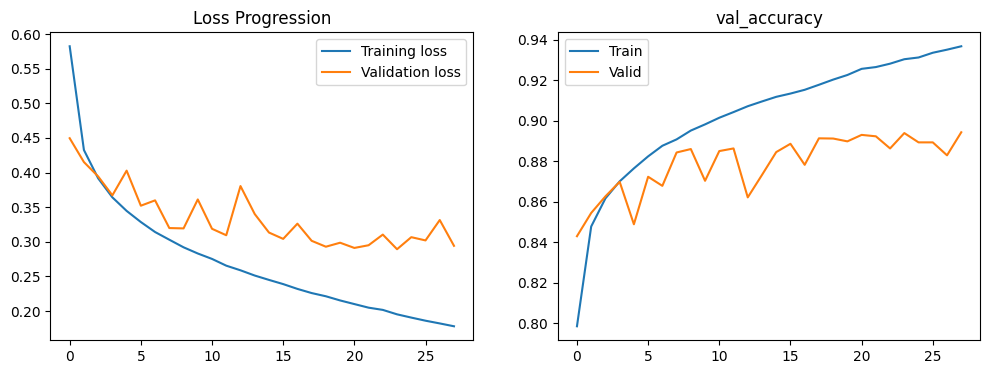

In [51]:
#1行2列でグラフを並べる例
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 左側にLoss
ax[0].plot(history['loss'], label='Training loss')
ax[0].plot(history['val_loss'], label='Validation loss')
ax[0].set_title("Loss Progression")
ax[0].legend()

# 右側にAccuracy
ax[1].plot(history['accuracy'], label="Train")
ax[1].plot(history['val_accuracy'], label="Valid")
ax[1].set_title("val_accuracy")
ax[1].legend()

plt.show()

In [52]:
class_name = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# --- 検証データを使った最終評価 ---
val_images = []
val_true_labels = []
val_pred_labels = []

mlp.eval()
with torch.no_grad():
    for x, t in dataloader_valid: # 検証データから取り出し
        x_dev = x.to(device)
        y = mlp(x_dev)
        pred = y.argmax(1).cpu().tolist()

        val_images.extend(x.numpy())
        val_true_labels.extend(t.tolist())
        val_pred_labels.extend(pred)

val_images = np.array(val_images)

# 混合行列表示
cm = confusion_matrix(val_true_labels, val_pred_labels)
cm_df = pd.DataFrame(cm, index=[["true"]*len(class_name), class_name], columns=[["pred"]*len(class_name), class_name])
# 合計追加
cm_df[("pred", "合計")] = cm_df.sum(axis=1)
cm_df.loc[("true", "合計"), :] = cm_df.sum(axis=0)
cm_df = cm_df.astype(int)
# 表示
display(cm_df.style.background_gradient(cmap="Blues", subset=pd.IndexSlice[cm_df.index[:-1], cm_df.columns[:-1]]))

In [53]:
class_names = [f"Class {i} : {name}" for i, name in enumerate(class_name)]
print(classification_report(val_true_labels, val_pred_labels, target_names=class_names))

                      precision    recall  f1-score   support

   Class 0 : T-shirt       0.86      0.84      0.85       985
   Class 1 : Trouser       0.98      0.98      0.98       977
  Class 2 : Pullover       0.82      0.81      0.82       971
     Class 3 : Dress       0.93      0.88      0.90      1018
      Class 4 : Coat       0.78      0.88      0.82      1020
    Class 5 : Sandal       0.97      0.95      0.96       946
     Class 6 : Shirt       0.75      0.71      0.73      1039
   Class 7 : Sneaker       0.95      0.96      0.95      1020
       Class 8 : Bag       0.97      0.97      0.97      1028
Class 9 : Ankle boot       0.96      0.96      0.96       996

            accuracy                           0.89     10000
           macro avg       0.90      0.89      0.90     10000
        weighted avg       0.90      0.89      0.89     10000



総サンプル数: 10000, 誤分類数: 1057


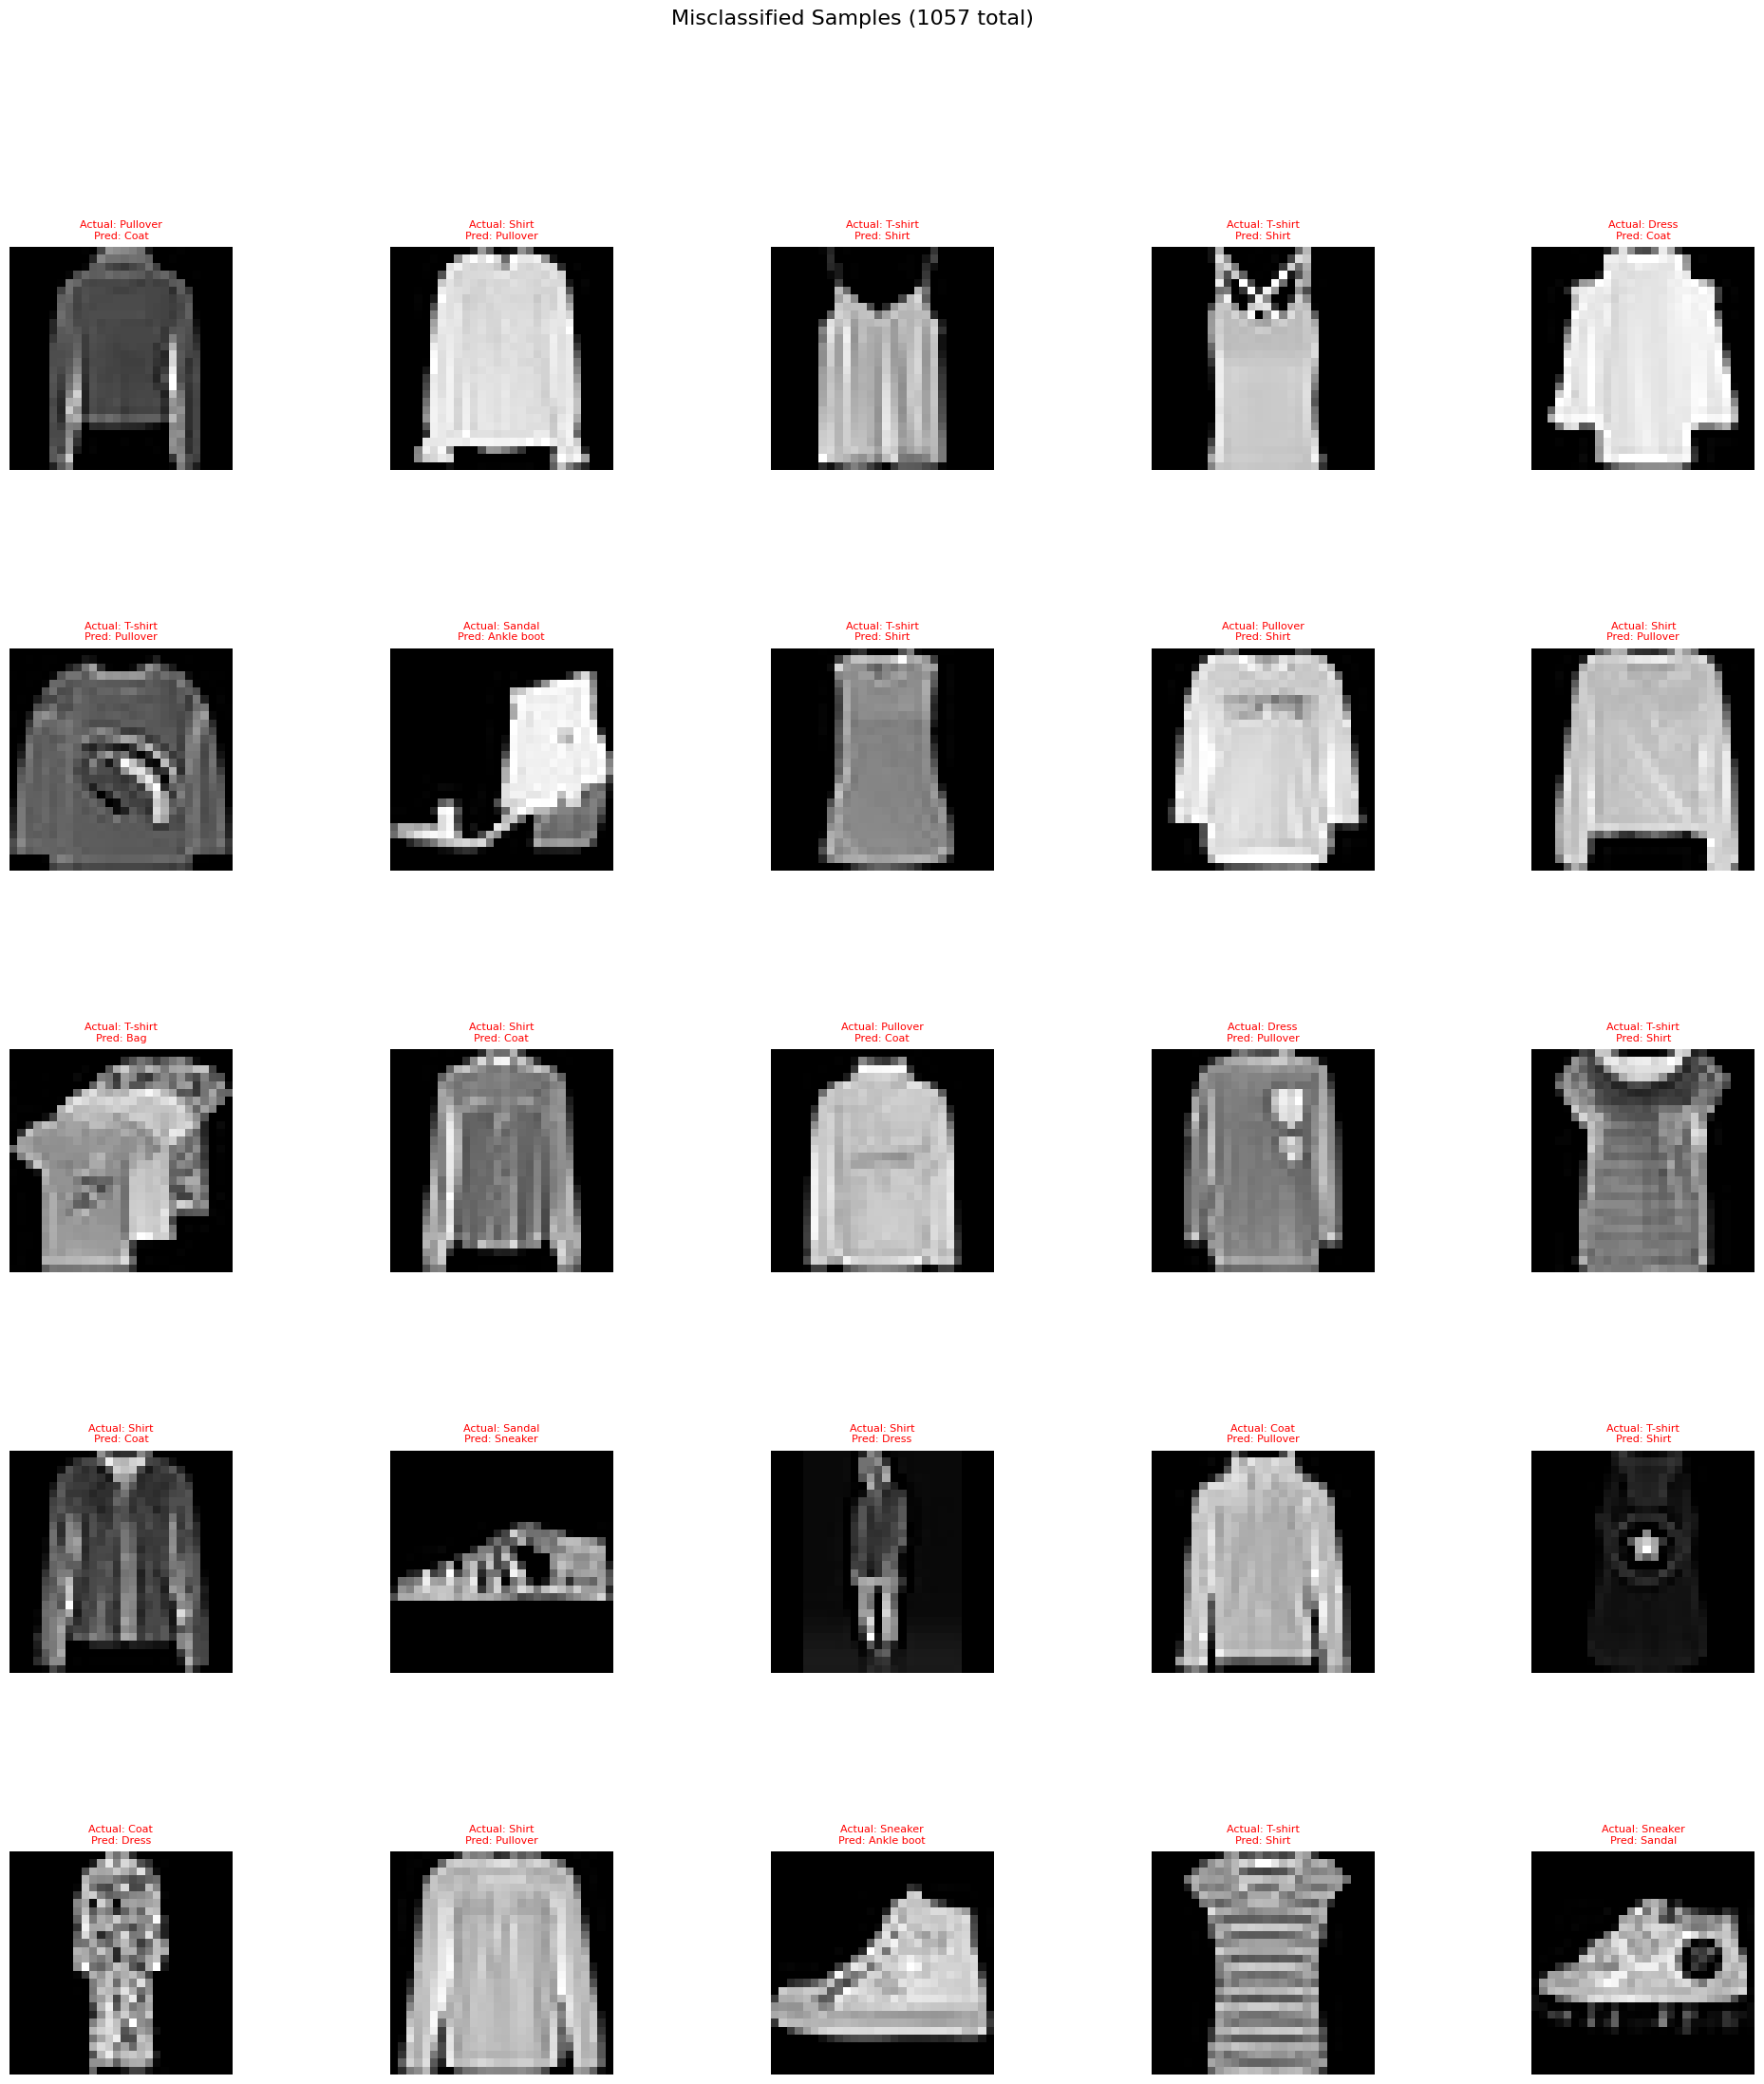

In [54]:
# --- 誤分類サンプルの可視化（検証データ） ---
wrong_indices = [i for i in range(len(val_true_labels)) if val_true_labels[i] != val_pred_labels[i]]
print(f"総サンプル数: {len(val_true_labels)}, 誤分類数: {len(wrong_indices)}")

grid_height = 5
grid_width = 5
max_display = grid_height * grid_width

fig, axes = plt.subplots(grid_height, grid_width, figsize=(25, 25))
axes = axes.ravel()

if len(wrong_indices) > 0:
    sampled = np.random.choice(wrong_indices, size=min(max_display, len(wrong_indices)), replace=False)

    for i, idx in enumerate(sampled):
        axes[i].imshow(val_images[idx].reshape(28, 28), cmap='gray')
        actual_name    = class_name[val_true_labels[idx]]
        predicted_name = class_name[val_pred_labels[idx]]
        axes[i].set_title(
            f"Actual: {actual_name}\nPred: {predicted_name}",
            fontsize=8, color='red'
        )
        axes[i].axis('off')
    # 余ったマスを非表示
    for i in range(len(sampled), max_display):
        axes[i].axis('off')
else:
    for i in range(max_display):
        axes[i].axis('off')

plt.suptitle(f"Misclassified Samples ({len(wrong_indices)} total)", fontsize=16)
plt.subplots_adjust(hspace=0.8)
plt.show()
